In [1]:
import sys
from pathlib import Path

scripts_dir = Path.cwd().parent.parent / "scripts"
sys.path.insert(0, str(scripts_dir))

In [2]:
# Path to test .mrxs
path_CMU1 = r"E:\Christine\testdata\CMU-1.mrxs"
path_CMU3 = r"E:\Christine\testdata\CMU-3.mrxs"
zarr_dir = r"E:\Christine\testdata\zarr"
cache_tissue = r"E:\Christine\testdata\cache_tissue_artifact.pkl"
cache_features = r"E:\Christine\testdata\feature_summary.csv"

slides = [path_CMU1, path_CMU3]

C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\site-packages\wsidata\io\_wsi.py:157: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = read_zarr(store)


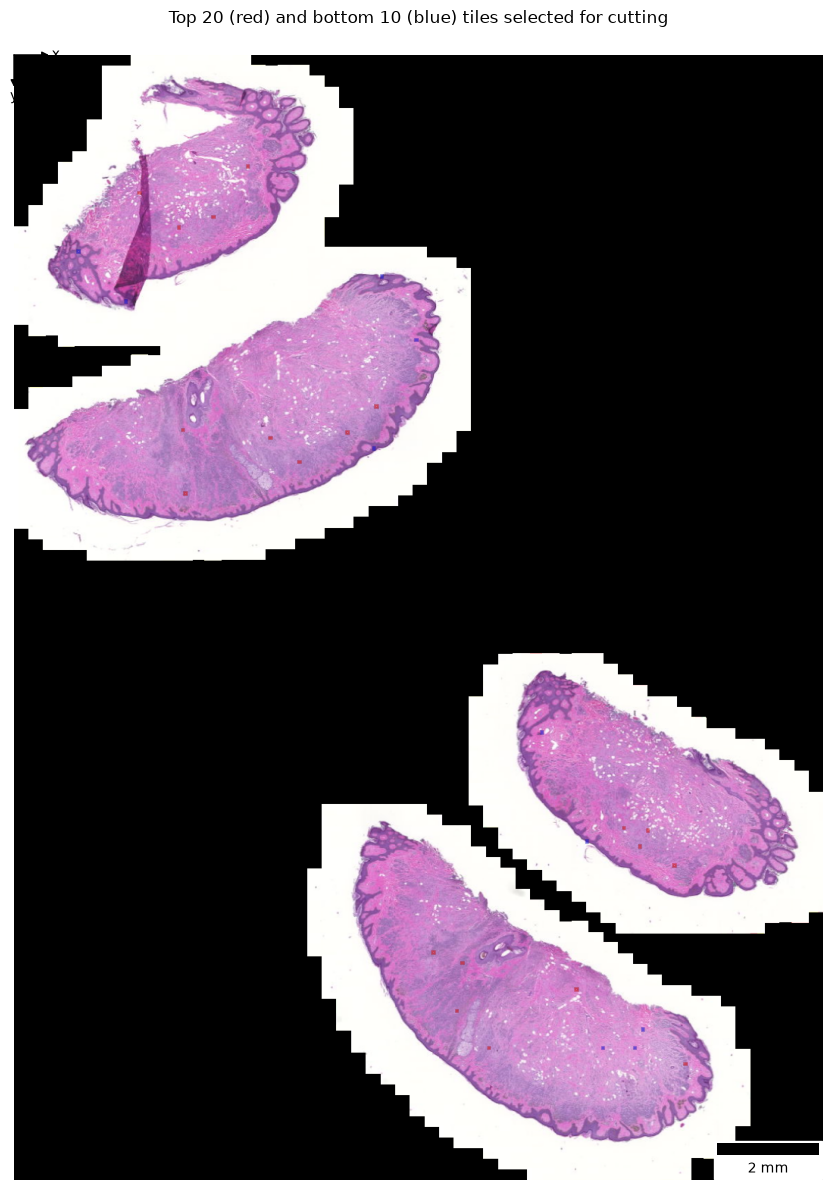

In [3]:
from roi_selection import ROISelector

inference_path = r"E:\Christine\testdata\inference.pkl"
path = slides[0]

selector = ROISelector(cache_path = inference_path, slide_path = path, top_k = 20, bottom_k = 10)
selector.tiles_to_cut()

In [4]:
sdata_lmd = selector.get_sdata_lmd()
top_polygons, bottom_polygons = selector.viewer_polygons()

In [5]:
import numpy as np
from interactive_viewer import launch_calibration_viewer

json_path = r"E:\Christine\testdata\CMU-3_annotations.json"
screenshot = r"E:\Christine\testdata\CMU-3_annotation_screenshots"

viewer, url = launch_calibration_viewer(
    slide_path=path,
    top_polygons=top_polygons,
    bottom_polygons=bottom_polygons,
    save_json=json_path,
    screenshot_dir=screenshot,
    polygon_input_order="xy",
    port=5000,
    open_browser=True,
    internet = True
)
url

=== WSI calibration viewer session ===
slide_path: E:\Christine\testdata\CMU-1.mrxs
slide_dimensions: (109240, 220696)
top_polygons: 20
bottom_polygons: 10
save_json: E:\Christine\testdata\CMU-3_annotations.json
screenshot_dir: E:\Christine\testdata\CMU-3_annotation_screenshots
internet: True
port: 64622
Viewer URL: http://127.0.0.1:64622/?session=2d0dccdb1f694d568dfad3a0aeee97b5&slide=CMU-1.mrxs


'http://127.0.0.1:64622/?session=2d0dccdb1f694d568dfad3a0aeee97b5&slide=CMU-1.mrxs'

In [ ]:
# Manually add calibration points (3 points, easy to locate on LMD)

In [ ]:
import json
import numpy as np
from spatialdata.models import PointsModel

# Load annotations
with open("annotations.json", "r") as f:
    ann = json.load(f)

# Extract calibration points as an (N, 2) array in image coordinates
cal_points = ann.get("calibration_points", [])
coords = np.array([[p["x"], p["y"]] for p in cal_points], dtype=float)

print("Calibration points (image coords):")
print(coords)

# Add to spatialdata object, in the same way you did with Napari
sdata_lmd.points["calibration_points"] = PointsModel.parse(coords)

In [ ]:
sdata_lmd

In [ ]:
H = sdata_lmd.images["wsi_thumbnail"].data.shape[1]
print(H)

In [ ]:
from dvpio.write import write_lmd
import os

lmd_dir = r"E:\Christine\testdata\lmd"

path_lmd = os.path.join(lmd_dir, "CMU1.xml")

# Transform coordinates from napari to LMD coordinate system
affine_transformation = np.array([
    [1,  0, 0],
    [0, -1, H],
    [0,  0, 1]
])

# Write LMD file with tiles and calibration points
write_lmd(
    path = path_lmd,
    annotation = sdata_lmd.shapes["top_tiles"],
    calibration_points=sdata_lmd.points["calibration_points"],
    affine_transformation=affine_transformation
)